# RT

In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

In [2]:
# Load integrated scene
scene = load_scene(sionna.rt.scene.munich) # Try also sionna.rt.scene.etoile

In [3]:
if not no_preview:
    scene.preview();

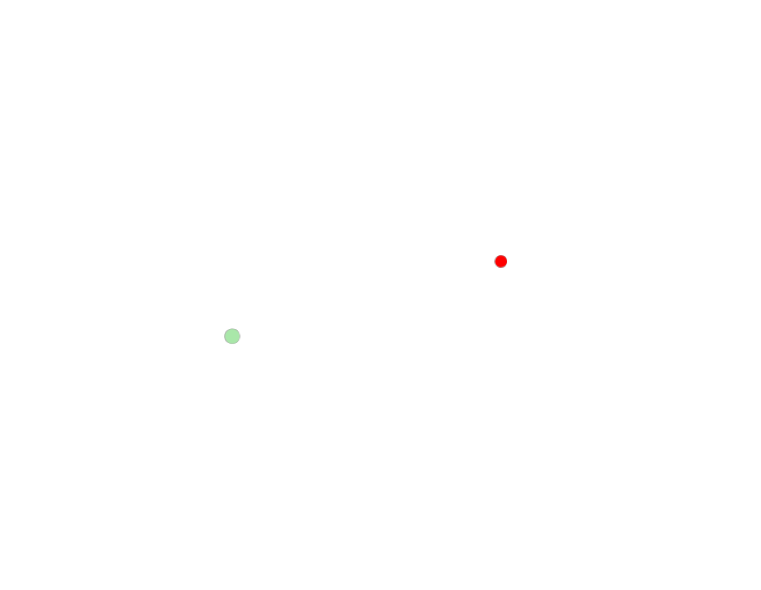

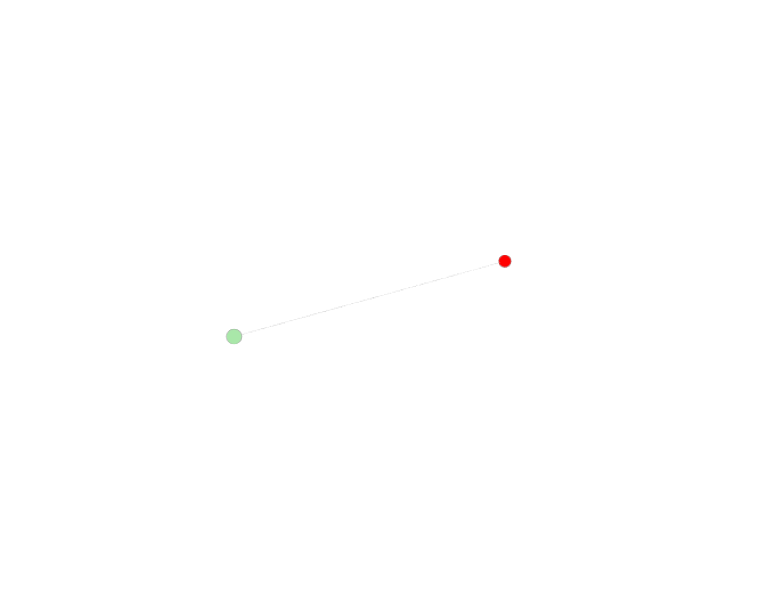

In [13]:
import numpy as np
from sionna.rt import Scene, Transmitter, Receiver, PathSolver


scene = Scene()

scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="tr38901", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="cross")


tx = Transmitter(name="tx", position=[0,0,0],display_radius=2 )
rx = Receiver(name="rx", position=[100,0,0], display_radius=2)

scene.add(tx)
scene.add(rx)

tx.look_at(rx)

# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=False,
                 synthetic_array=False,
                 seed=41)

# Create new camera with different configuration
my_cam = Camera(position=[200,200,100], look_at=[50,0,0])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);
else:
    scene.preview(paths=paths, clip_at=20);


In [2]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
batch_size = 1000 # Number of symbols we want to generate
num_bits_per_symbol = 4 # 16-QAM has four bits per symbol
binary_source = sionna.phy.mapping.BinarySource()
b = binary_source([batch_size, num_bits_per_symbol])
b

<tf.Tensor: shape=(1000, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 1., 1., 0.],
       ...,
       [1., 1., 1., 0.],
       [0., 1., 0., 0.],
       [1., 1., 0., 0.]], dtype=float32)>

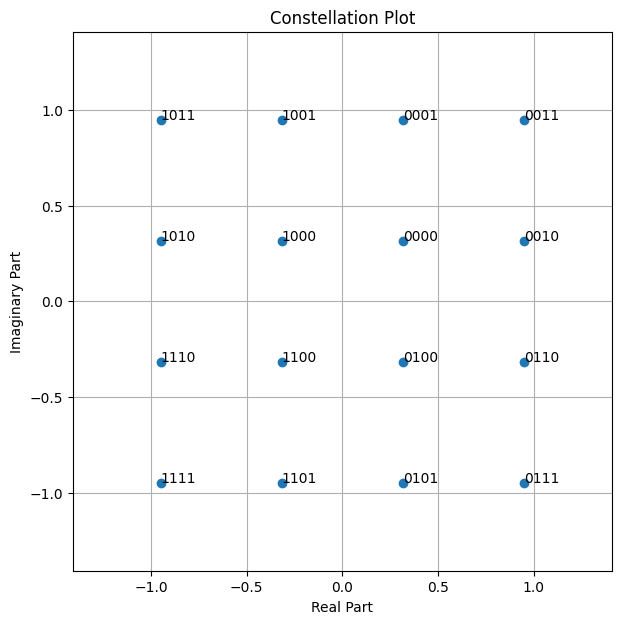

In [4]:
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
constellation.show();

In [5]:
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
x = mapper(b)
x[:10]


<tf.Tensor: shape=(10, 1), dtype=complex64, numpy=
array([[-0.31622776+0.31622776j],
       [ 0.31622776-0.31622776j],
       [-0.94868326-0.31622776j],
       [-0.31622776+0.94868326j],
       [-0.94868326+0.31622776j],
       [-0.31622776-0.31622776j],
       [ 0.31622776-0.94868326j],
       [-0.94868326-0.94868326j],
       [ 0.94868326-0.94868326j],
       [-0.94868326-0.94868326j]], dtype=complex64)>

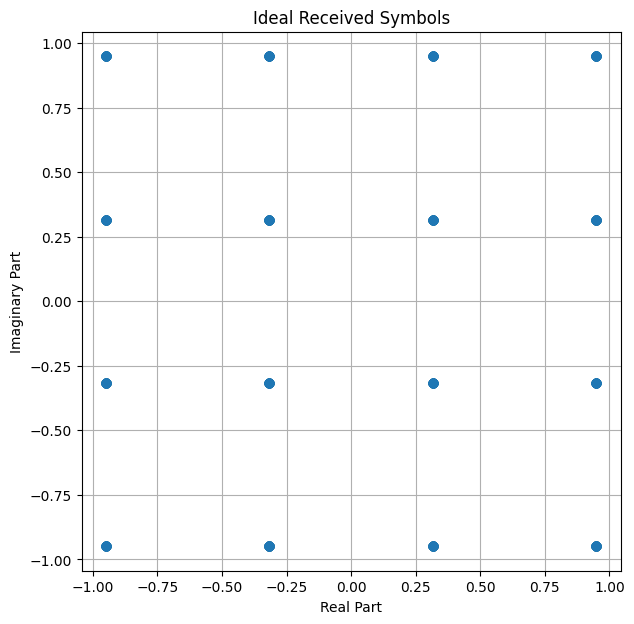

In [7]:
#awgn = sionna.phy.channel.AWGN()
ebno_db = 15 # Desired Eb/No in dB
no = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate=1)
y = x

# Visualize the received signal
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.scatter(np.real(y), np.imag(y));
ax.set_aspect("equal", adjustable="box")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True, which="both", axis="both")
plt.title("Ideal Received Symbols");